There's too much going on in Gordon's notebook to resolve any issues we're having with an individual plot.  Construct the L--z plot in this single notebook.

In [18]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import palettable
import richardsplot as rplot
from astropy.cosmology import FlatLambdaCDM; cosmo = FlatLambdaCDM(Om0=0.3, H0=70)
from astropy.table import Table

In [19]:
plt.rcParams['xtick.top']   = True
plt.rcParams['ytick.right'] = True

#use this color palette throughout
cs = palettable.colorbrewer.qualitative.Dark2_5.mpl_colors

In [20]:
def plot_contour_fast2(xdata, ydata, c="k", mark=".", nlevels=3, ax=None,
                      linewidths=0.5, s=3, alpha=1, label=None):

    if ax is None:
        ax = plt.gca()

    dx = 0.1 * (xdata.max() - xdata.min())
    dy = 0.1 * (ydata.max() - ydata.min())

    xmin, xmax = xdata.min() - dx, xdata.max() + dx
    ymin, ymax = ydata.min() - dy, ydata.max() + dy

    X, Y = np.mgrid[xmin:xmax:60j, ymin:ymax:60j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    values = np.vstack([xdata, ydata])

    kernel = stats.gaussian_kde(values, bw_method=0.2)
    Z = kernel(positions).reshape(X.shape)

    from scipy.ndimage import gaussian_filter
    Z = gaussian_filter(Z, sigma=1.0)          # enforce smooth topology
    Z /= Z.max()                               # normalize safely

    cs = ax.contour(X, Y, Z, levels=nlevels,
                    linewidths=linewidths, colors=[c])
    levels = cs.levels

    from scipy.interpolate import RegularGridInterpolator
    interp = RegularGridInterpolator(
        (X[:, 0], Y[0, :]), Z,
        bounds_error=False, fill_value=Z.min()
    )

    z = interp(np.column_stack((xdata, ydata)))
    mask = z > levels[0]

    ax.scatter(xdata[~mask], ydata[~mask],
               s=s, c=c, marker=mark, alpha=alpha, label=label)


In [3]:
def plot_contour(xdata, ydata, c="k", mark=".", nlevels=3, ax=None, linewidths=0.5, s=3, alpha=1, label=None):
    if ax is None:
        ax = plt.gca()
    xmin, xmax = xdata.min()-0.25*abs(xdata.mean()), xdata.max()+0.25*abs(xdata.mean())
    ymin, ymax = ydata.min()-0.25*abs(ydata.mean()), ydata.max()+0.25*abs(ydata.mean())
    X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    values = np.vstack([xdata, ydata])
    kernel = stats.gaussian_kde(values)
    Z = np.reshape(kernel(positions).T, X.shape)
    z = kernel(values)
    
    #transform Z to a 0-1 range
    Z = (Z - Z.min())/(Z.max() - Z.min())
    z = (z - z.min())/(z.max() - z.min())
    
    #ax.contour(X, Y, Z, levels=nlevels, linewidths=1.5, colors=c)
    levels = ax.contour(X, Y, Z, levels=nlevels, linewidths=linewidths, colors=[c]).levels
    
    # mask points above density threshold
    x = np.ma.masked_where(z > levels[0], xdata)
    y = np.ma.masked_where(z > levels[0], ydata)
    ax.scatter(x, y, color=c, marker=mark, s=3, alpha=alpha, zorder=2, label=label)

---

Load data.  First from HST; includes 130 S07 objects and additional 78 HSLA objects with ICA.  N=208

In [ ]:
hst = pd.read_csv("HST_CIV_Sulentic2007_HSLA2018_finalprops_f2500AP.csv")
#comment out next line if want to include "bad" CIV measurements
# hst = hst[hst["CIVgood_manmask"].values==1]
hst.head()

,Final_Name,Alt_Name,Inst_final,z,z_src,CIV_blue_tvm,CIV_EW_tvm,_RA,_DE,Sul_Name,...,logLEdd_Source,logLEdd_Source_qual,F2500 (ergs/s/cm2/A),F2500_change,logLbol_2500 (erg/s),logLedd (erg/s),logEddRatio_2500,CIV_Distance,Spec_Name,F2500_AP
0,1H0707-495,2MASS J07084147-4933063,STIS,0.04080,Sul,1437.482252,6.095122,107.173050,-49.551842,J07086-4933,...,NaN,NaN,6.785221e-15,6.785221e-15,44.295900,44.400371,-0.104471,0.896653,J07086-4933,6.792626e-15
1,1H1613-097,2MASS J16151905-0936132,HSLA,0.06496,https://arxiv.org/pdf/2108.11958.pdf,59.381212,68.570031,243.829000,-9.603690,NaN,...,NaN,NaN,2.591391e-15,2.591391e-15,44.296881,45.040371,-0.743489,0.395527,1H1613-097,2.440854e-15
2,2E1013,PKS 0420-01,FOS,0.91500,Sul,-78.781269,58.892013,65.815836,-1.342518,J04232-0120,...,NaN,NaN,2.515154e-16,2.515154e-16,45.877265,47.130371,-1.253106,0.432297,J04232-0120,2.162104e-16
3,2E1135,PKS 0439-43,FOS,0.59380,Sul,335.512559,68.375473,70.322167,-43.229278,J04412-4313,...,NaN,NaN,1.229594e-15,1.229594e-15,46.103335,46.180371,-0.077036,0.396815,J04412-4313,1.118576e-15
4,2E1644,IRAS L06229-6434,HSLA,0.12900,https://arxiv.org/pdf/1710.10703.pdf,-493.636575,80.774877,95.782000,-64.605800,NaN,...,NaN,NaN,5.858584e-15,5.858584e-15,45.271568,45.900371,-0.628803,0.352018,IRAS-L06229-6434,5.418938e-15


In [5]:
len(hst)

207

In [6]:
hst.columns

Index(['Final_Name', 'Alt_Name', 'Inst_final', 'z', 'z_src', 'CIV_blue_tvm',
       'CIV_EW_tvm', '_RA', '_DE', 'Sul_Name', 'SDSS_NAME', 'PLATE', 'MJD',
       'FIBERID', 'F1450_spec (erg/s/cm2/A)', 'S2N_1450A', 'CIVgood_manmask',
       'F1550_sul07', 'c1_2_sul07', 'log M_BH', '+err(log M_BH)',
       '-err(log M_BH)', 'MBH_source', 'MBH_source_qual', 'logEddRatio',
       'EddRatio_Source', 'EddRatio_Source_qual', 'LBol', 'LBol Source',
       'LBol_Source_qual', 'logLEdd', 'logLEdd_Source', 'logLEdd_Source_qual',
       'F2500 (ergs/s/cm2/A)', 'F2500_change', 'logLbol_2500 (erg/s)',
       'logLedd (erg/s)', 'logEddRatio_2500', 'CIV_Distance', 'Spec_Name',
       'F2500_AP'],
      dtype='object')

In [22]:
names_hst = hst["Final_Name"].values

z_hst    = hst["z"].values
DLcm_hst = cosmo.luminosity_distance(z_hst).value*3.086e24 #convert Mpc to cm 

#compute luminosities in erg/s/Hz
#first convert flambda to fnu
fnu2500_hst    = hst["F2500_AP"].values * 2500. / (2.998e18/2500)
logLnu2500_hst = np.log10(4.*np.pi) + np.log10(fnu2500_hst) + 2*np.log10(DLcm_hst) + np.log10(1.+z_hst)

In [8]:
c4blueICA_hst  = hst["CIV_blue_tvm"].values
c4logewICA_hst = np.log10(hst["CIV_EW_tvm"].values)
c4blueS07_hst  = -1*hst["c1_2_sul07"].values
c4distICA_hst = hst["CIV_Distance"].values

#save mask for points that actually belong to the Sulentic sample
maskS07 = (~np.isnan(c4blueS07_hst))
#save mask for points that have RM BH mass measurements
maskMBH    = (~np.isnan(hst["log M_BH"].values))
maskMBH_rm = maskMBH&(hst["MBH_source_qual"].values<2)
maskMBH_sr = maskMBH&(hst["MBH_source_qual"].values>=2)

---

And plot -- plan is to plot everything "as is".  That is, if there's no ICA measurement for a dataset, I'm not plotting it so we know where we stand.

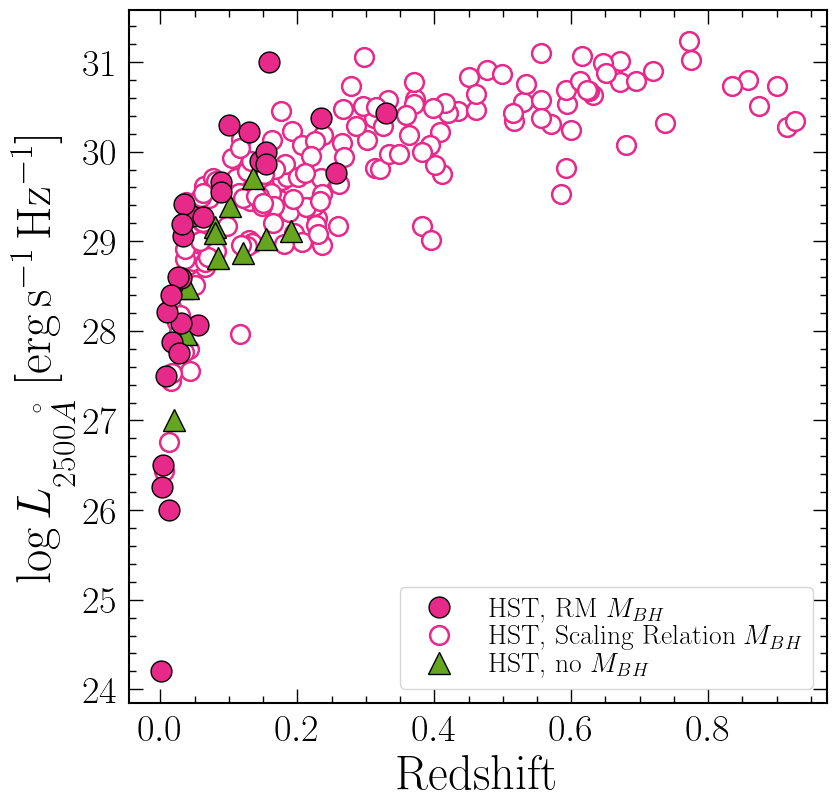

In [9]:
ALPHA_ORIG = 0.25

##
fig, ax = plt.subplots(1, 1, figsize=(9,9))

###Next block of code plots the HST sample
#plot ICA measurements
ax.plot(z_hst[maskMBH_rm], logLnu2500_hst[maskMBH_rm], marker="o", markersize=15, 
        markerfacecolor=cs[3], markeredgecolor="k", label="HST, RM $M_{BH}$", linestyle="", zorder=3)
ax.plot(z_hst[maskMBH_sr], logLnu2500_hst[maskMBH_sr], marker="o", markersize=13.5, 
        markerfacecolor="w", markeredgecolor=cs[3], mew=1.8, label="HST, Scaling Relation $M_{BH}$", linestyle="", zorder=2)
ax.plot(z_hst[~maskMBH], logLnu2500_hst[~maskMBH], marker="^", markersize=16.5, 
        markerfacecolor=cs[4], markeredgecolor="k", label="HST, no $M_{BH}$", linestyle="", zorder=2)

#plot settings
ax.set_xlabel('Redshift', fontsize=35)
ax.set_ylabel(r'log\,$L_{2500\AA}$ [erg\,s$^{-1}$\,Hz$^{-1}$]', fontsize=35)
ax.tick_params(axis='both', which='major', labelsize=27.5)
#ax.legend(frameon=True, labelspacing=0.1, bbox_to_anchor=(1.0,1), prop={"size":20})
ax.legend(frameon=True, labelspacing=0.1, loc="lower right", prop={"size":20})

#ax.set_ylim(-499.99, 5999)
#plt.xlim(26.5,32.3)
plt.show()

<hr style="border:15px solid gray">

Now include SDSS objects.  For now, these are ~145,000 DR14 objects with CIV from Rankine+20. 

To remain as consistent as possible with the HST objects, I pulled L1350 measurements from Wu & Shen's spectral properties of DR16.

In [10]:
sdss_tbl = Table.read("Rankine20_CIV_HeII_wDelGI_wdr16luminosity.fits")
names = [name for name in sdss_tbl.colnames if len(sdss_tbl[name].shape) <= 1]
sdss = sdss_tbl[names].to_pandas()
#next line cuts objects without luminosity at logL1350 (15828/145946, maybe just not in spectra?)
sdss = sdss[(sdss["LOGL2500_dr16"]>0)&(sdss["good"]==True)]
sdss.head()

,SDSS_NAME,RA,Dec,z_paul,good,nBAL,CIV_blue,CIV_EW,HeII_EW,MI,...,FUV_IVAR,NUV,NUV_IVAR,FIRST_FLUX,FIRST_SNR,Delta_G_I,EBV_dr16,LOGL1350_dr16,LOGL2500_dr16,CIV_Distance
0,b'003708.46+002855.8',9.285266,0.482174,3.02295,True,False,691.966469,75.072475,3.192852,-27.453024,...,45.552314,-0.018692,3.531072,-1.0,-1.0,0.600,0.020385,45.751832,45.721232,0.373444
2,b'015017.70+002902.4',27.573786,0.484025,3.00333,True,False,1474.865400,31.916310,0.551262,-27.999413,...,1074.827534,0.183702,373.859257,-1.0,-1.0,0.167,0.032827,46.482924,46.471169,0.681618
4,b'072047.82+405455.5',110.199280,40.915418,3.04179,True,False,195.093283,106.332340,8.233896,-25.954803,...,7.126986,0.070899,32.722264,-1.0,-1.0,-0.159,0.053382,45.686672,45.869747,0.282193
6,b'073346.60+465836.2',113.444183,46.976735,2.19711,True,False,820.113836,46.306361,2.011977,-25.812672,...,4.586199,-0.047932,217.287807,-1.0,-1.0,0.291,0.109363,45.253213,45.464793,0.552542
8,b'074717.69+483917.4',116.823739,48.654850,1.88349,True,False,1255.186285,37.172600,0.724905,-25.267284,...,20.541693,0.221892,269.526076,-1.0,-1.0,0.057,0.047917,45.369878,45.325064,0.634468


In [59]:
sdss_name = sdss["SDSS_NAME"].values
sdss_name = np.array([name.decode() for name in sdss_name])

In [11]:
lognuLnu2500_sdss = sdss["LOGL2500_dr16"].values
logLnu2500_sdss   = lognuLnu2500_sdss - np.log10(2.9918e18/2500)

z_sdss = sdss["z_paul"].values

In [12]:
sdss_temple = pd.read_csv("Fig1Data_sdss_withTempleL3000.csv")
z_sdss_temple   = sdss_temple["Z_SDSS"].values
logLnu2500_sdss_temple = sdss_temple["L3000_THB21"].values - 14.9775 #convert from L3000 to L2500

mask_sdss_temple = ~np.isnan(logLnu2500_sdss_temple)
z_sdss_temple = z_sdss_temple[mask_sdss_temple]
logLnu2500_sdss_temple = logLnu2500_sdss_temple[mask_sdss_temple]

---

Now add GNIRS-DQS.  Found 196/226 matches to Rankine+20.

In [13]:
gnirs = pd.read_csv("gnirsdqs_wRankine_wdr16Lum.csv")
gnirs = gnirs[((gnirs["good"]==True)&(gnirs["LOGL2500_dr16"].values>0))]
gnirs

,SDSS,FWHM-Hb,EW-Hb,EW-Fe2,RA,DEC,z_paul,good,CIV_blue,CIV_EW,FIRST_FLUX,Delta_G_I,EBV_dr16,LOGL1350_dr16,LOGL2500_dr16,Separation,CIV_dist_ICA_tvm
0,b' J010615.93+101043.0',2936,73,2,16.566375,10.178611,2.349550,True,1370.747782,29.741127,-1.00,0.255,0.038158,46.468226,46.339400,0.076726,0.682983
1,b' J141617.38+264906.1',4574,29,9,214.072417,26.818361,2.303360,True,5184.405058,10.884853,2.94,0.820,0.013895,46.429107,46.634516,0.058456,1.251156
2,b' J011538.72+242446.0',3925,51,34,18.911333,24.412778,2.389560,True,1980.043140,26.444624,-1.00,0.014,0.043618,46.825398,46.619689,0.090241,0.764178
3,b' J093533.88+235720.5',6686,94,2,143.891167,23.955694,2.303190,True,342.276646,43.004758,-1.00,0.072,0.022259,46.803522,46.736122,0.085507,0.518977
5,b' J114350.30+362911.3',4090,48,13,175.959583,36.486472,2.356160,True,1548.446448,21.157348,-1.00,0.098,0.016090,47.013947,46.895565,0.087221,0.758010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,b' J093251.98+023727.0',5521,48,31,143.216583,2.624167,2.164804,True,1555.979001,39.276915,-1.00,0.235,0.038693,46.362684,46.518544,0.039926,0.654849
216,b' J145541.11-023751.0',4632,73,2,223.921292,-2.630833,1.613420,True,531.243264,69.504123,-1.00,0.038,0.081693,0.000000,46.263450,0.066335,0.392967
219,b' J160552.97+292141.4',4192,64,2,241.470708,29.361500,2.325757,True,659.730040,55.427849,-1.00,0.438,0.033625,46.580814,46.706964,0.076767,0.496048
222,b' J134341.99+255652.9',9204,43,2,205.924958,25.948028,1.604080,True,700.055566,22.206089,-1.00,0.406,0.010986,0.000000,46.733155,0.000468,0.665383


In [14]:
lognuLnu2500_gnirs    = gnirs["LOGL2500_dr16"].values
logLnu2500_gnirs      = lognuLnu2500_gnirs - np.log10(2.998e18/2500)

z_gnirs = gnirs["z_paul"].values

In [15]:
def L2500toLbol(L2500):
    return 0.9869*(np.log10(2.998e18/1549.48)+L2500) + 1.051

def LboltoL2500(Lbol):
    return (Lbol-1.051)/0.9869 - np.log10(2.998e18/1549.48)

C:\Users\Alexandros Pratsos\AppData\Local\Temp\ipykernel_39012\3161026322.py:37: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(xdata[~mask], ydata[~mask],


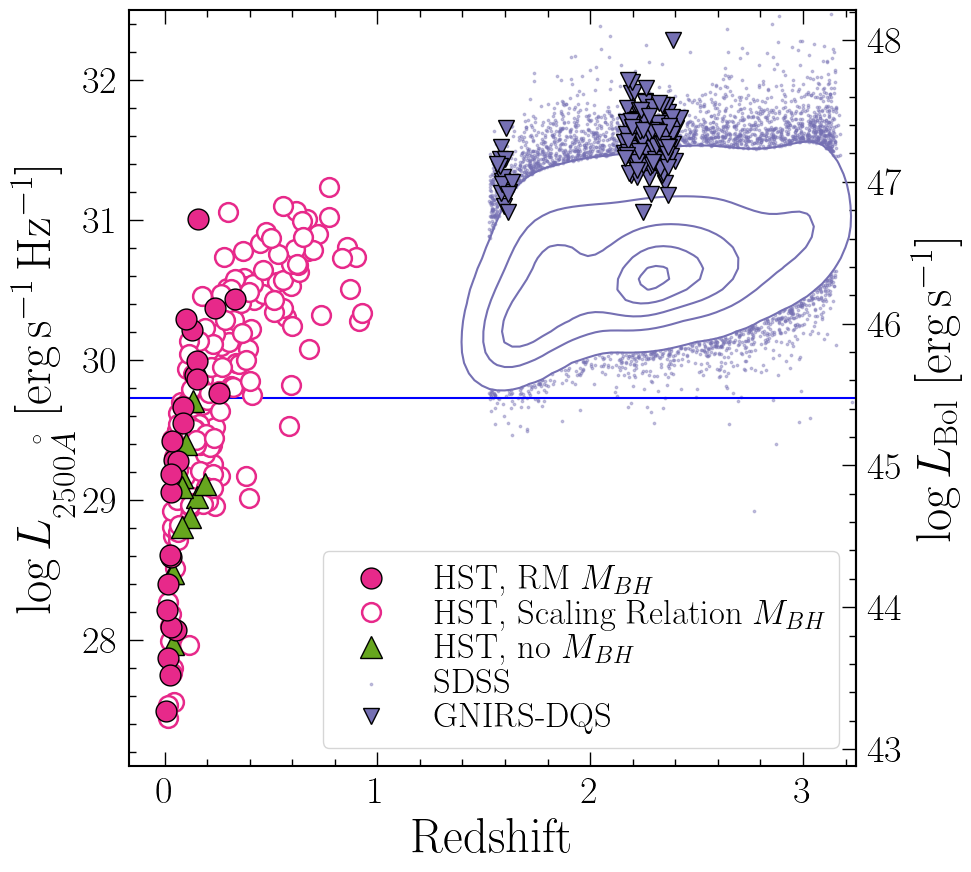

In [16]:
plt.rcParams["ytick.right"] = False

ALPHA_ORIG = 0.25
fig, ax = plt.subplots(1, 1, figsize=(10,9))

### Next block of code plots the HST sample
#plot ICA measurements
ax.plot(z_hst[maskMBH_rm], logLnu2500_hst[maskMBH_rm], marker="o", markersize=15, 
        markerfacecolor=cs[3], markeredgecolor="k", label="HST, RM $M_{BH}$", linestyle="", zorder=3)
ax.plot(z_hst[maskMBH_sr], logLnu2500_hst[maskMBH_sr], marker="o", markersize=13.5, 
        markerfacecolor="w", markeredgecolor=cs[3], mew=1.8, label="HST, Scaling Relation $M_{BH}$", linestyle="", zorder=2)
ax.plot(z_hst[~maskMBH], logLnu2500_hst[~maskMBH], marker="^", markersize=16.5, 
        markerfacecolor=cs[4], markeredgecolor="k", label="HST, no $M_{BH}$", linestyle="", zorder=2)


### Next block of code plots SDSS and GNIRS-DQS objects
#N.B. this block takes a while, so should comment out when testing
plot_contour_fast2(z_sdss, logLnu2500_sdss, c=cs[2], mark="o", nlevels=[0.05, 0.25, 0.50, 0.75, 0.95], ax=ax, 
             linewidths=1.5, s=3, alpha=0.4, label="SDSS")
             
#ax.plot(z_sdss, logLnu2500_sdss, marker="o", markersize=3, color=cs[2], alpha=0.35, 
#        label="SDSS", linestyle="", zorder=1)

#now GNIRS
ax.plot(z_gnirs, logLnu2500_gnirs, marker="v", markersize=11, markerfacecolor=cs[2], markeredgecolor="k", label="GNIRS-DQS", linestyle="", zorder=3)

#plot settings
ax.set_xlabel('Redshift', fontsize=35)
ax.set_ylabel(r'log\,$L_{2500\AA}$ [erg\,s$^{-1}$\,Hz$^{-1}$]', fontsize=35)
ax.tick_params(axis='both', which='major', labelsize=27.5)
#ax.legend(frameon=True, labelspacing=0.1, bbox_to_anchor=(1.0,1), prop={"size":20})
ax.legend(frameon=True, labelspacing=0.1, loc="lower right", prop={"size":25})

secax = ax.secondary_yaxis('right', functions=(L2500toLbol, LboltoL2500))
secax.set_ylabel(r'log\,$L_\mathrm{Bol}$ [erg\,s$^{-1}$]', fontsize=35)
secax.tick_params(labelsize=27.5)
L2500_threshold = LboltoL2500(np.log10(3e45))
ax.plot([-1e5,1e5], [L2500_threshold,L2500_threshold], "-b", zorder=1)

ax.set_ylim(27.1, 32.5)
ax.set_xlim(-0.16575, 3.25)

plt.tight_layout()
plt.savefig("L_versus_z_ICA.pdf")
plt.show()

C:\Users\Alexandros Pratsos\AppData\Local\Temp\ipykernel_39012\3161026322.py:37: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(xdata[~mask], ydata[~mask],


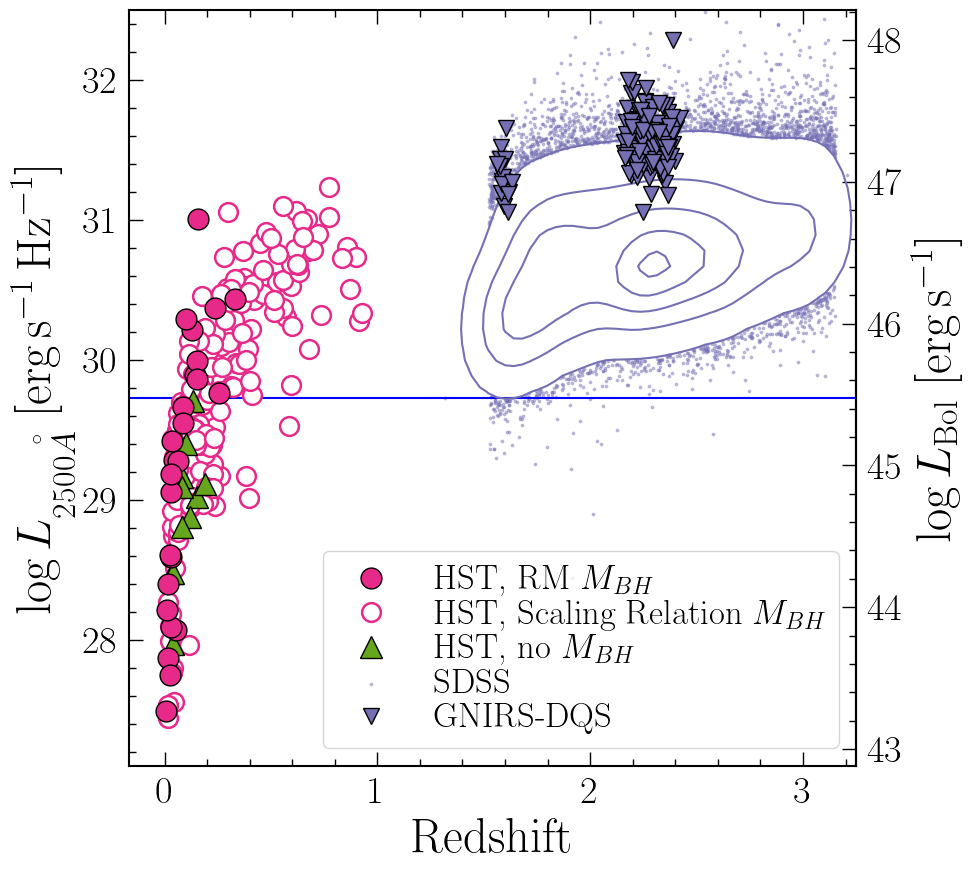

In [17]:
plt.rcParams["ytick.right"] = False

ALPHA_ORIG = 0.25
fig, ax = plt.subplots(1, 1, figsize=(10,9))

### Next block of code plots the HST sample
#plot ICA measurements
ax.plot(z_hst[maskMBH_rm], logLnu2500_hst[maskMBH_rm], marker="o", markersize=15, 
        markerfacecolor=cs[3], markeredgecolor="k", label="HST, RM $M_{BH}$", linestyle="", zorder=3)
ax.plot(z_hst[maskMBH_sr], logLnu2500_hst[maskMBH_sr], marker="o", markersize=13.5, 
        markerfacecolor="w", markeredgecolor=cs[3], mew=1.8, label="HST, Scaling Relation $M_{BH}$", linestyle="", zorder=2)
ax.plot(z_hst[~maskMBH], logLnu2500_hst[~maskMBH], marker="^", markersize=16.5, 
        markerfacecolor=cs[4], markeredgecolor="k", label="HST, no $M_{BH}$", linestyle="", zorder=2)


### Next block of code plots SDSS and GNIRS-DQS objects
#N.B. this block takes a while, so should comment out when testing
plot_contour_fast2(z_sdss_temple, logLnu2500_sdss_temple, c=cs[2], mark="o", nlevels=[0.05, 0.25, 0.50, 0.75, 0.95], ax=ax, 
             linewidths=1.5, s=3, alpha=0.4, label="SDSS")
             
#ax.plot(z_sdss, logLnu2500_sdss, marker="o", markersize=3, color=cs[2], alpha=0.35, 
#        label="SDSS", linestyle="", zorder=1)

#now GNIRS
ax.plot(z_gnirs, logLnu2500_gnirs, marker="v", markersize=11, markerfacecolor=cs[2], markeredgecolor="k", label="GNIRS-DQS", linestyle="", zorder=3)

#plot settings
ax.set_xlabel('Redshift', fontsize=35)
ax.set_ylabel(r'log\,$L_{2500\AA}$ [erg\,s$^{-1}$\,Hz$^{-1}$]', fontsize=35)
ax.tick_params(axis='both', which='major', labelsize=27.5)
#ax.legend(frameon=True, labelspacing=0.1, bbox_to_anchor=(1.0,1), prop={"size":20})
ax.legend(frameon=True, labelspacing=0.1, loc="lower right", prop={"size":25})

secax = ax.secondary_yaxis('right', functions=(L2500toLbol, LboltoL2500))
secax.set_ylabel(r'log\,$L_\mathrm{Bol}$ [erg\,s$^{-1}$]', fontsize=35)
secax.tick_params(labelsize=27.5)
L2500_threshold = LboltoL2500(np.log10(3e45))
ax.plot([-1e5,1e5], [L2500_threshold,L2500_threshold], "-b", zorder=1)

ax.set_ylim(27.1, 32.5)
ax.set_xlim(-0.16575, 3.25)

plt.tight_layout()
plt.savefig("L_versus_z_ICA_Temple_SDSS.pdf")
plt.show()